In [ ]:
# ## '''Installation'''
# !pip install qiskit[visualization]
# # Use the following if you are on MacOS/zsh
# #!pip install 'qiskit[visualization]'==1.1.0
# !pip install qiskit_aer
# !pip install qiskit_ibm_runtime
# !pip install matplotlib
# !pip install pylatexenc
# !pip install prototype-zne

## For Particle in a Box with Potential V
$$U = e^{-iV\Delta t }QFT e^{-iT\Delta t} QFT_{inv} $$



In [1]:
# import of required libraries and modules
from math import pi
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit.circuit.library import QFTGate as QFT
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator

### Initial wavefunction
For now, We will be working on a Gaussian stationary wavefunction with initial kinetic energy $k_0=300$:
$$\psi(x,t_{0}) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-x_{0}}{\sigma}\right)^{2}} e^{i\hbar k_{0}x}$$

## Step Potential

In [4]:
# sampler = StatevectorSampler()
def initialization(qc,wavefunction,q_reg):

    qc.initialize(wavefunction, q_reg)

def apply_QFT(qc,q_reg,n):
    qc.append(QFT(num_qubits=n), q_reg)


def Time_Evolution(qc,n,q_reg,aux_reg):
    # qc=QuantumCircuit(q_reg,aux_reg)
    for i in range (n):
        qc.p(phi/(2**(i+n-3)),q_reg[n-i-1])
    for i in range (n):
        for j in range (i+1,n):
            qc.cx(q_reg[n-j-1], aux_reg[0])
            qc.cx(q_reg[n-i-1], aux_reg[0])
            qc.p(phi* (2**(2-i-j)), aux_reg[0]) 
            qc.cx(q_reg[n-i-1], aux_reg[0])
            qc.cx(q_reg[n-j-1], aux_reg[0])
            # qc.barrier()
    # qc.to_gate()


def apply_invQFT(qc,q_reg,n):
    qc.append(QFT(num_qubits=n).inverse(), q_reg)

def display_histogram(qc, q_reg, c_reg, n, plot=False, hist=True, backend=AerSimulator(), shots=4096, probabilities=False,iter=iter,title="title"):
    qc.measure(q_reg,c_reg)
    keys = range(0,2**n)
    counts= {key: 0 for key in keys}
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    transpiled_qc = pm.run(qc)
    sampler = Sampler(backend)
    job = sampler.run([transpiled_qc], shots=shots)
    result = job.result()[0]
    raw_counts = result.data.classical.get_counts()
    
    # Convert binary string keys to integers to match the x-axis
    formatted_counts = {int(k, 2): v for k, v in raw_counts.items()}
    
    # Fill in missing values for the full range 0-63
    full_counts = {i: formatted_counts.get(i, 0) for i in range(2**n)}

    probabilities = {i: formatted_counts.get(i, 0) /shots for i in range(2**n)}
    
    if hist:
        if probabilities:
            fig = plot_histogram(probabilities,bar_labels=False,figsize=(10, 5))
            ax = fig.axes[0]
            # Add title for the histogram indicating the iteration number i and title:"Free particle"
            ax.title.set_text(f"{title} - Iteration {iter}")
            step_pos = 16
            step_height = 0.15  # Adjust this based on your y-axis scale
            x_max = 63         # Adjust this to the end of your x-axis (number of bins - 1)

            # 2. Draw the vertical line (the "step")
            ax.vlines(x=step_pos, ymin=0, ymax=step_height, color='red', linestyle='--', linewidth=2, label='Potential Step')

            # 3. Draw the horizontal line (the "barrier top")
            ax.hlines(y=step_height, xmin=step_pos, xmax=x_max, color='red', linestyle='--', linewidth=2)

            # 4. Optional: Draw the ground potential (x-axis) for clarity
            ax.hlines(y=0, xmin=0, xmax=step_pos, color='black', linewidth=1)
            # ax.set_ylim(0, 0.5)   # 👈 FIXED y-axis
            display(fig)

            # display(plot_histogram(probabilities, bar_labels=False,figsize=(10,5),) )
        else:
            display(plot_histogram(full_counts, bar_labels=False,figsize=(10,5)))
      
    if plot:
        plt.figure(figsize=(10, 5))
        if probabilities:
            plt.plot(list(probabilities.keys()), list(probabilities.values()))
            # plt.ylim(0, 0.5)
            plt.title("Wavefunction Probability Distribution")
            plt.xlabel("State Index")
            plt.ylabel("Probability")
            plt.show()
            return
        else:
            plt.plot(list(full_counts.keys()), list(full_counts.values()))
            plt.title("Wavefunction Probability Distribution")
            plt.xlabel("State Index")
            plt.ylabel("Probability")
            plt.show()


## Step Potential

V is at qubit n=6

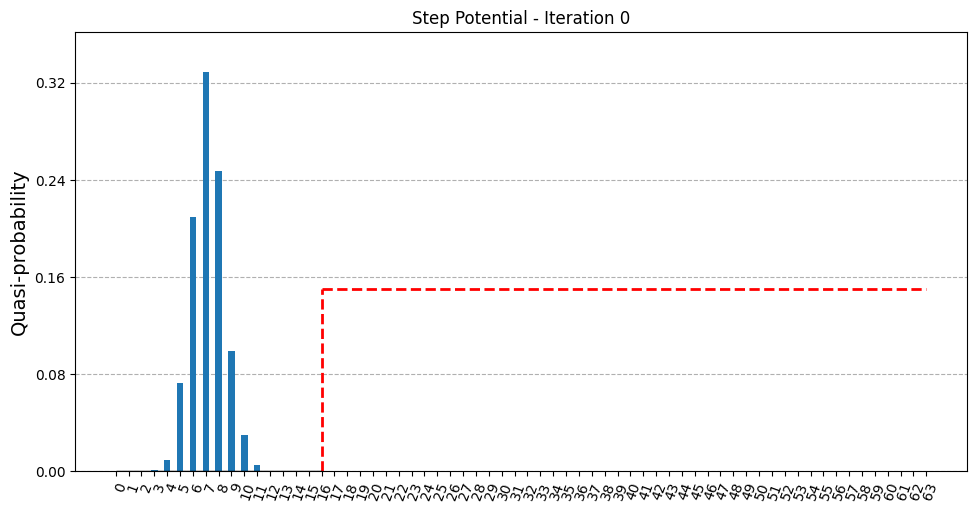

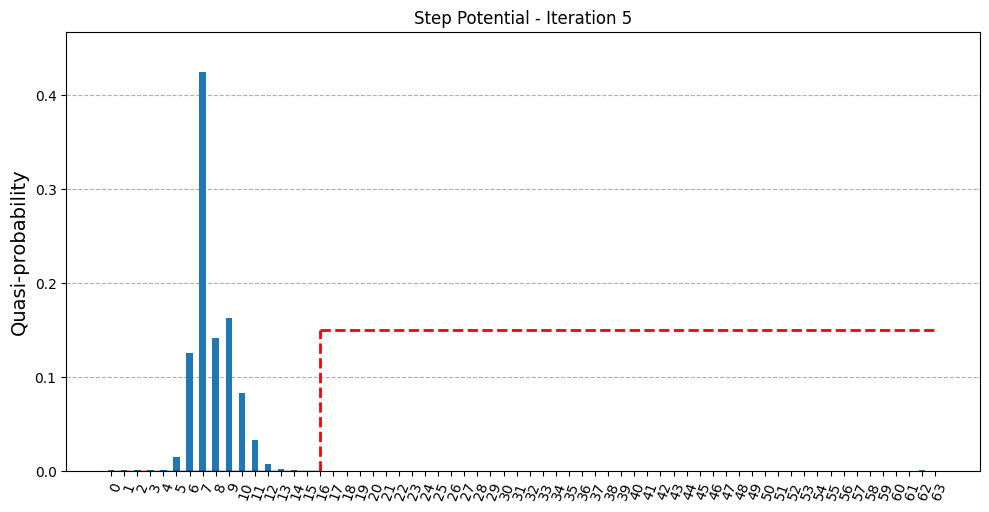

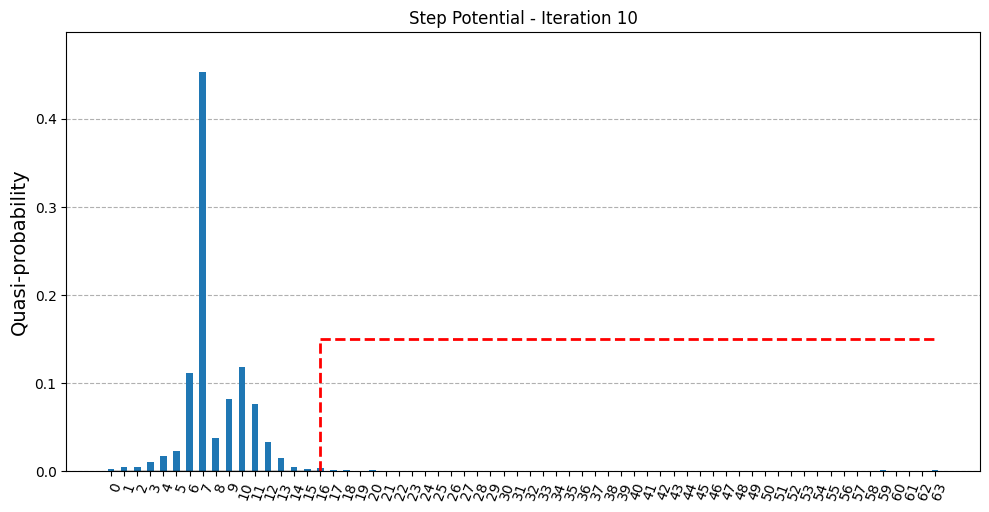

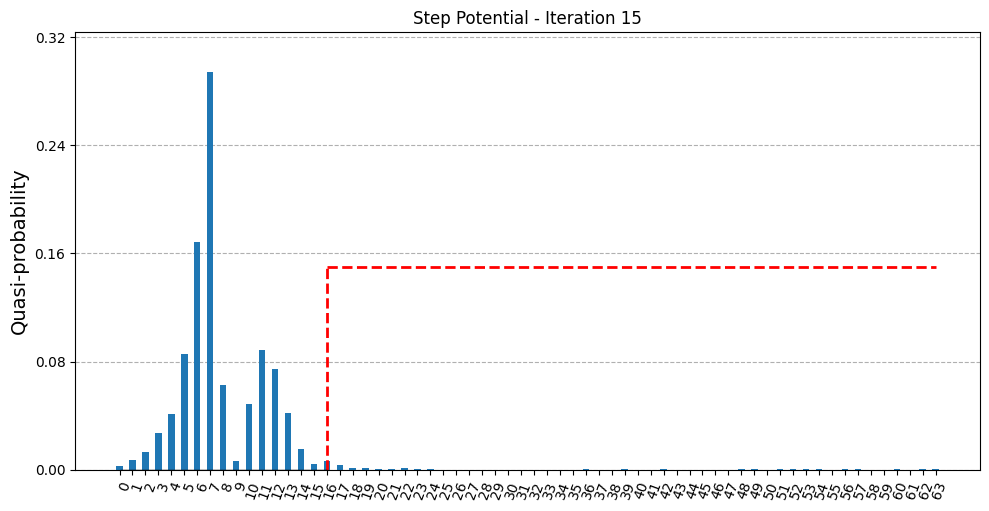

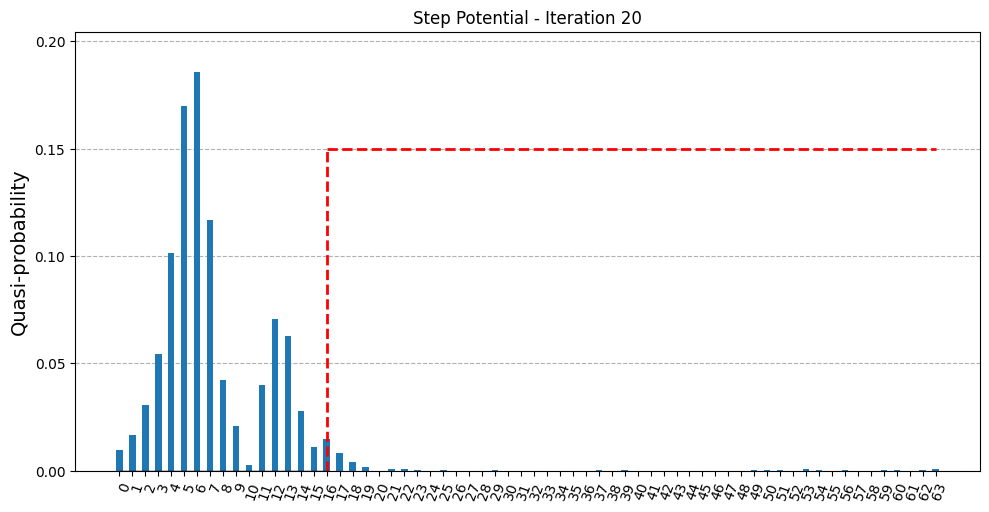

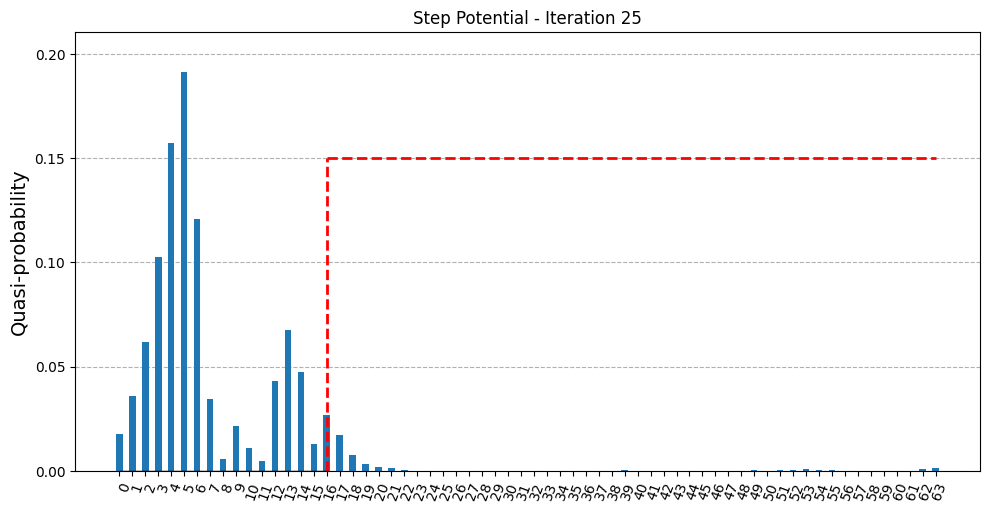

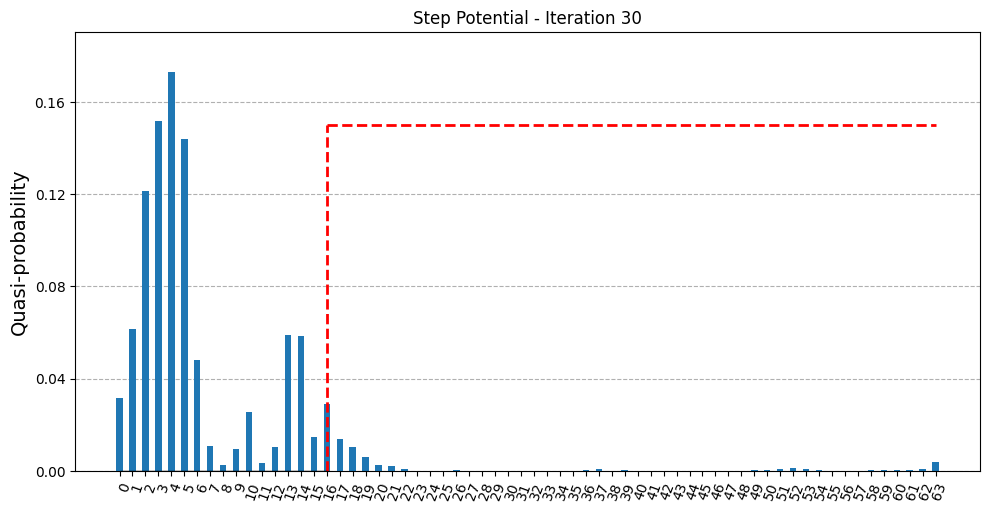

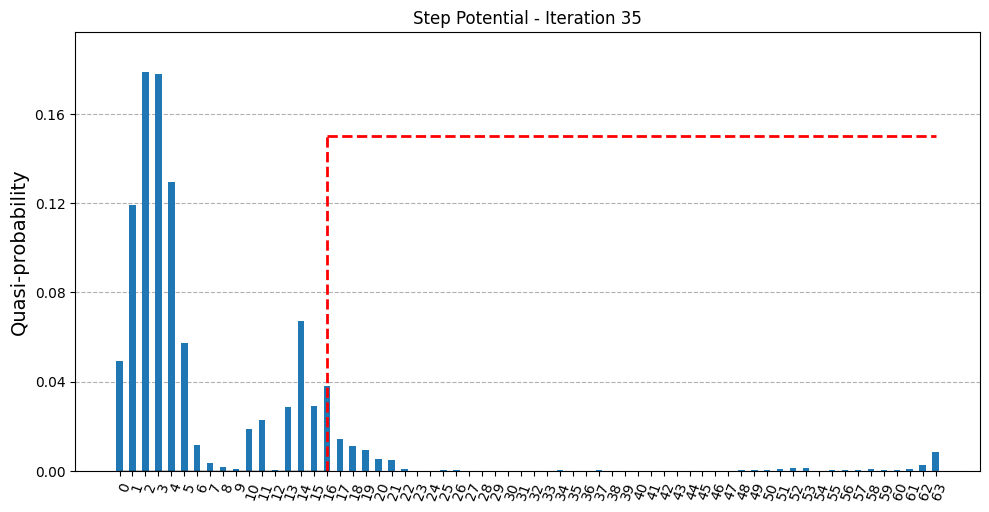

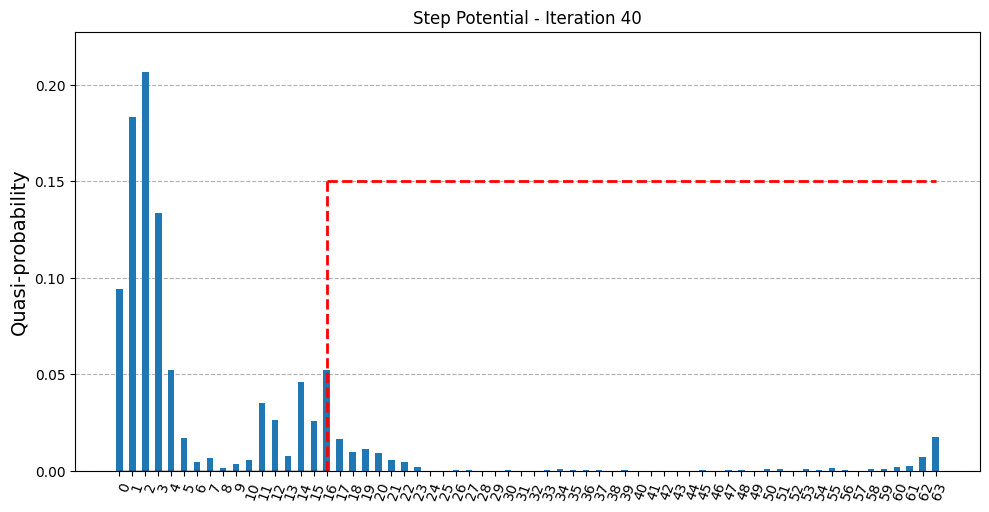

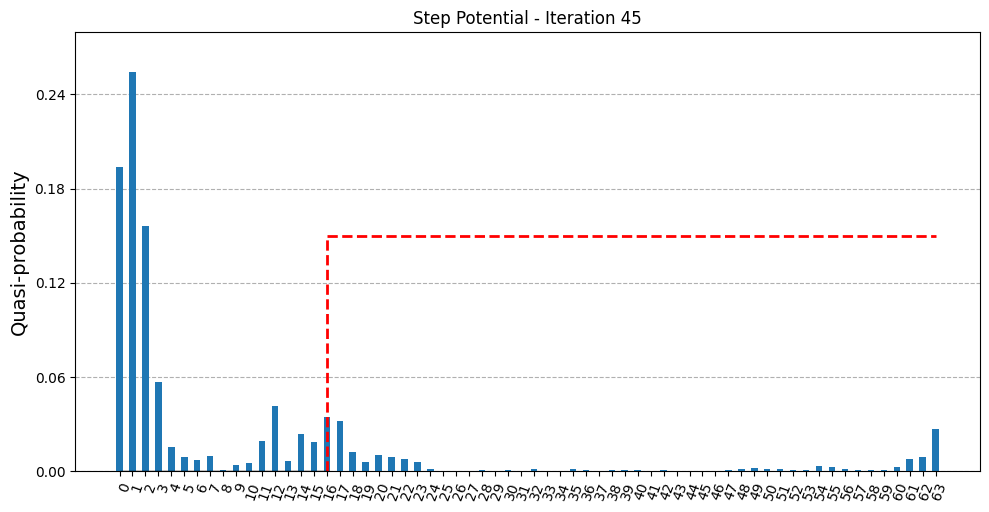

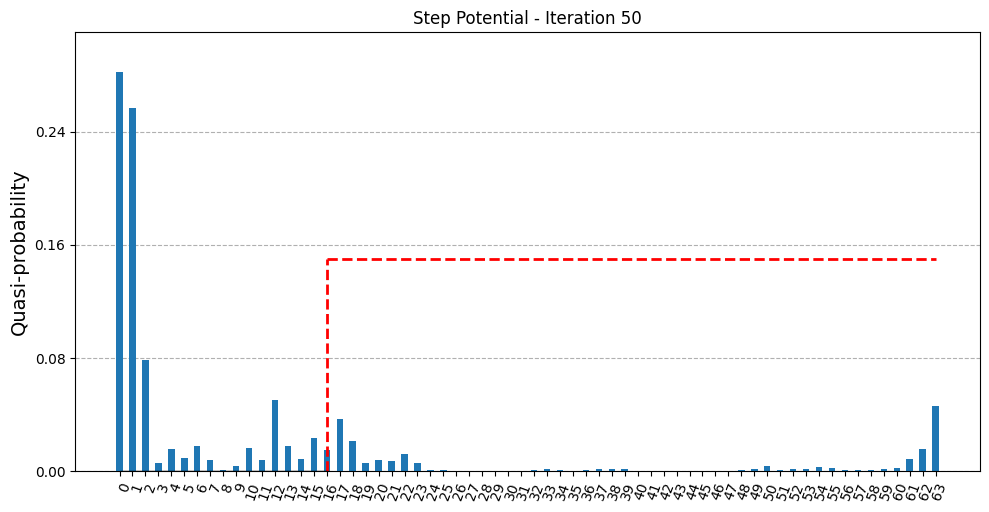

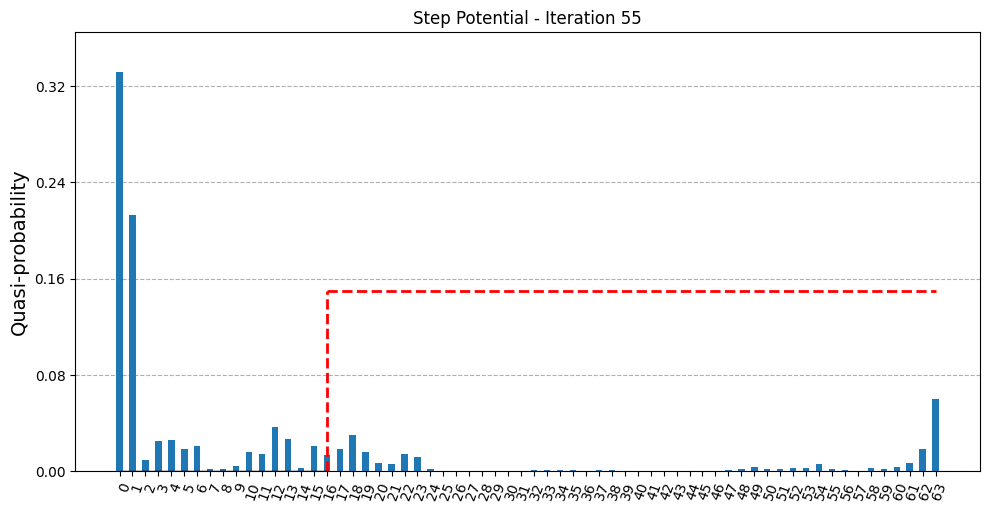

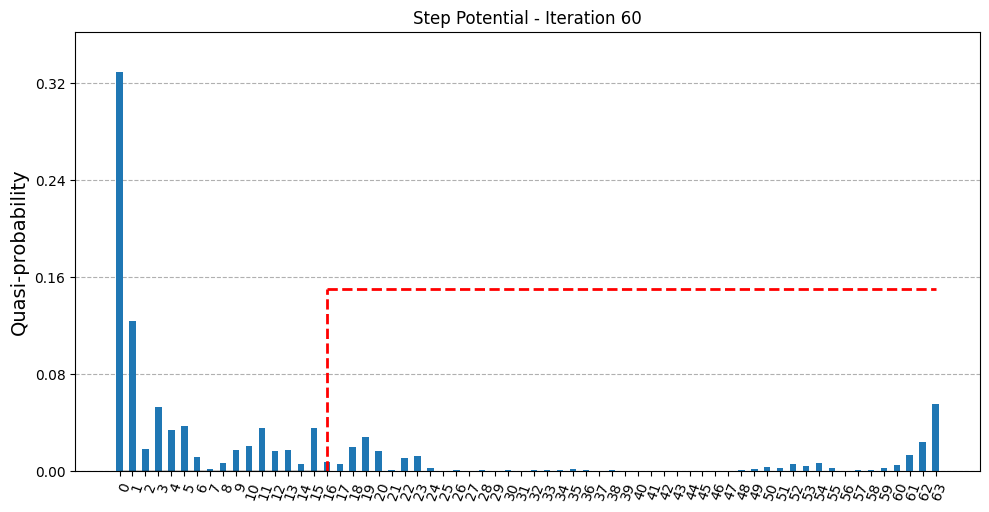

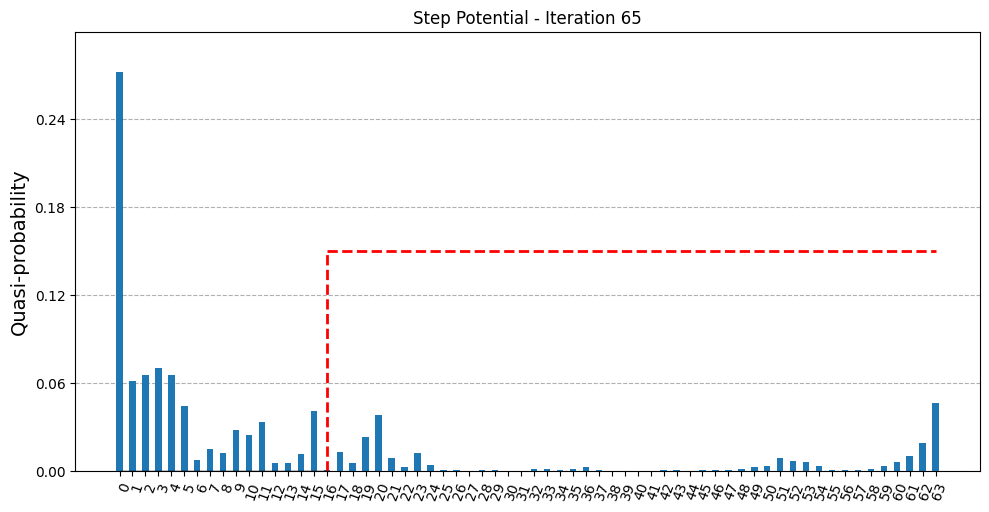

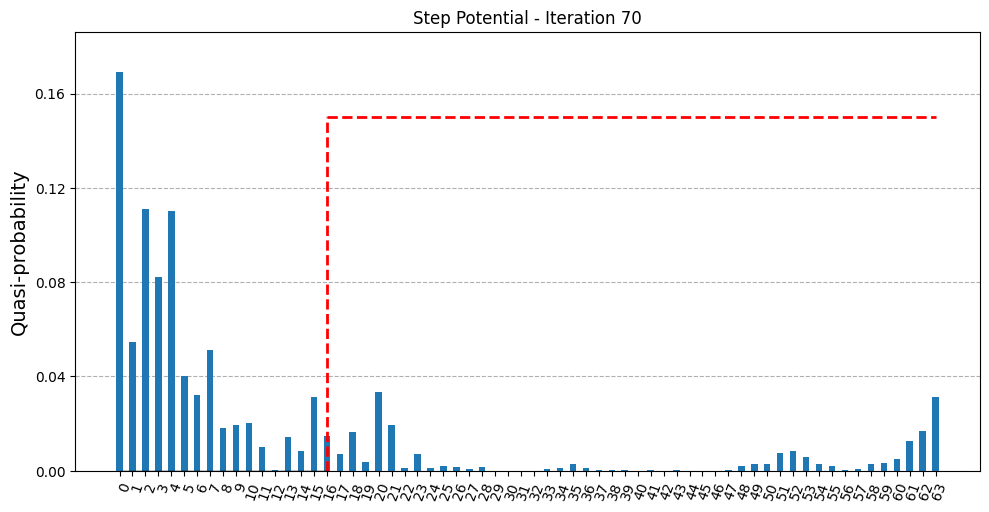

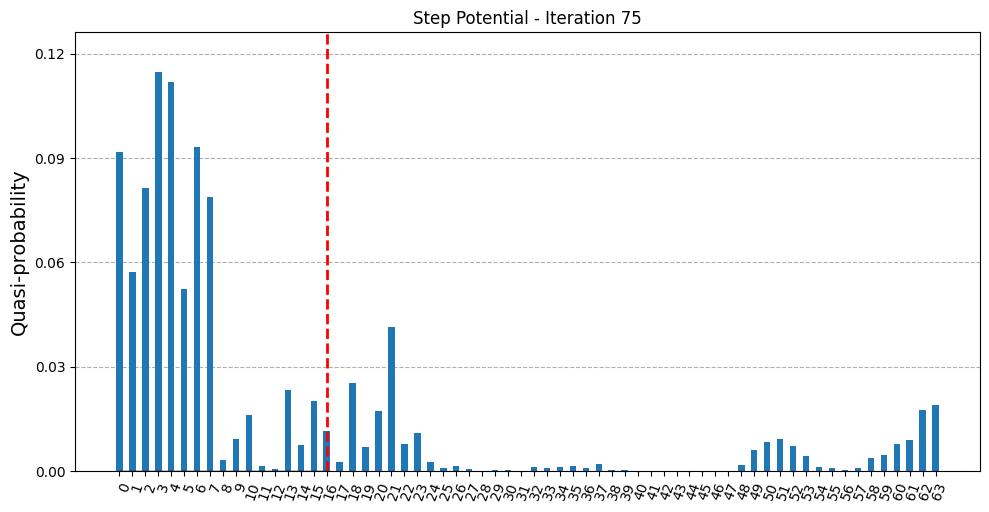

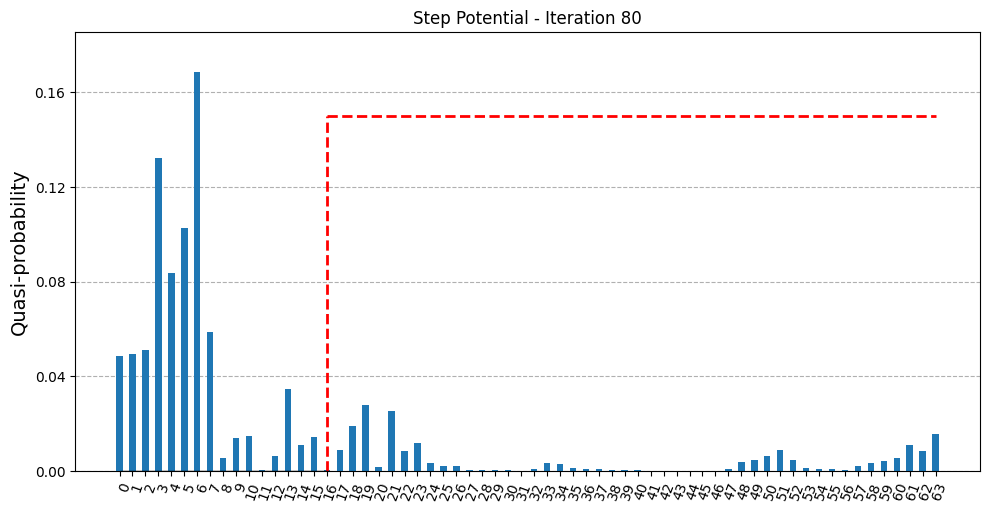

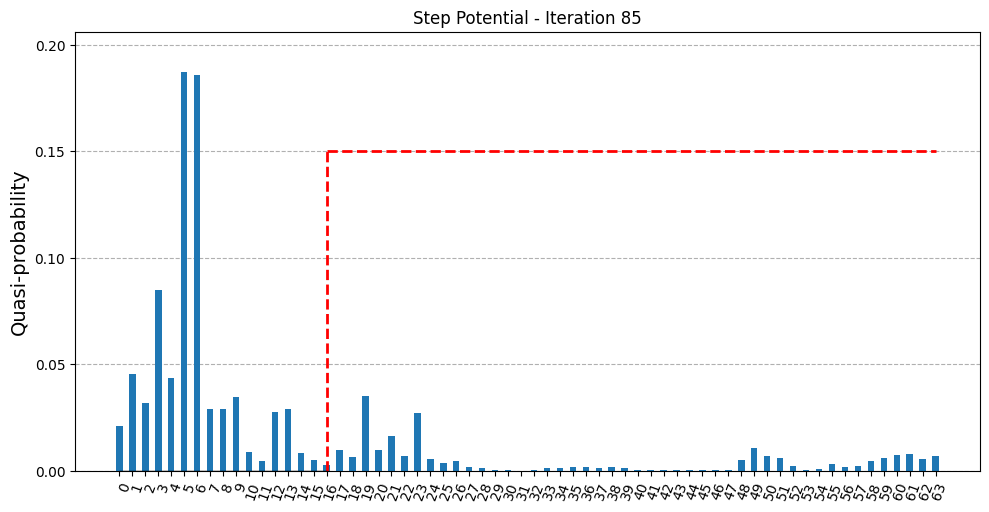

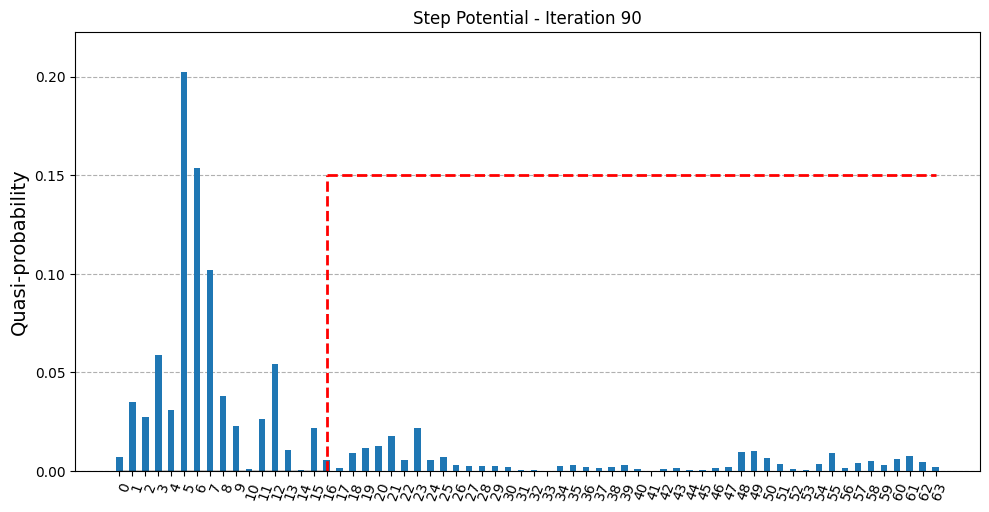

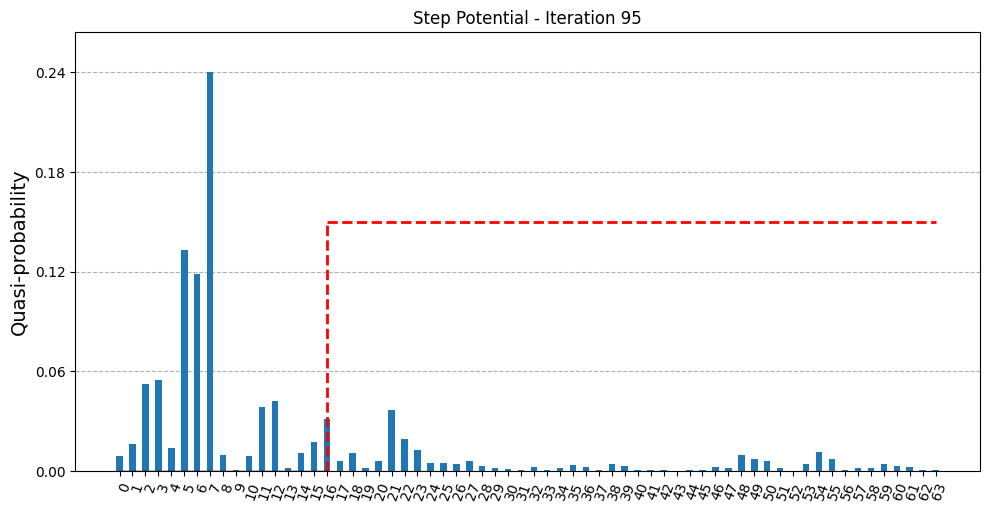

In [5]:
x = np.linspace(-0.5,4, num=64)
'''wavefunction: guassian wavepacket with moving forward(+ve x axis) in time'''
x0=0
hk=-3
V=2
phi=0.1
unnormalized_wavefunction= (1/(np.sqrt(2*np.pi)*0.4)*np.exp(-(0.5*(x-x0)**2)/(0.016)))*np.exp(300j*x)


Normalisation_Constant = np.sqrt(np.sum(np.abs(unnormalized_wavefunction**2)))

forward_wave = (unnormalized_wavefunction)/(Normalisation_Constant)


# plt.plot(x,forward_wave)
# plt.show()
def evolve(iter,wavefunction,n=6,plot=False,hist=True):
    phi = 0.1  # function of time step
    q_reg=QuantumRegister(6)
    aux_reg=QuantumRegister(1)
    clas_reg = ClassicalRegister(6,'classical')
    qc=QuantumCircuit(aux_reg,q_reg,clas_reg)
    initialization(qc,wavefunction,q_reg)
    i=0
    snaps=[]
    for i in range(iter):
        qc.p(V*phi,4)

        # qc.ccx(4,3,0)
        # qc.cp(V*phi,0,5)
        # qc.ccx(4,3,0)

        # qc.cx(4,0)
        # qc.cp(V*phi,0,5)
        # qc.cx(4,0)

        apply_QFT(qc,q_reg,n) 
        qc.x(n)
        Time_Evolution(qc,n,q_reg,aux_reg)
        qc.x(n) 
        apply_invQFT(qc,q_reg,n)
        if i%5==0:
            snap = qc.copy()
            display_histogram(snap,q_reg,clas_reg,n,plot=plot,hist=hist,probabilities=True,iter=i,title="Step Potential")
            # snaps.append(qc.copy())
        i=i+1
        


evolve(iter=100,wavefunction=forward_wave,n=6,plot=False,hist=True)

## Quantum Tunnelling


In [8]:
import qiskit
print(qiskit.version.get_version_info())

2.3.0
